# 整理数据

保存四个地点的1周预见期的预报数据为例

In [1]:
import xarray as xr
import numpy as np
from pyenspp.csgemos.fitter import CSGDFitter
import matplotlib.pyplot as plt
import os

os.chdir(r'D:\Paper\ESE\data')

In [ ]:
obs = xr.open_dataset('./mswep/obs1w.nc')
raw = xr.open_dataset('./tp/tp_ens1w.nc')

# 四个城市坐标
cities = {
    "Guangzhou": (113.24, 23.1291),
    "Beijing": (116.4074, 39.9042),
    "Zhengzhou": (113.65, 34.76),
    "Wuxi": (120.30, 31.57)
}

# 1. 提取城市名称和对应的经纬度
city_names = list(cities.keys())
lon_vals = [coord[0] for coord in cities.values()]
lat_vals = [coord[1] for coord in cities.values()]

# 2. 构造符合 xarray 批量高维索引（Advanced Indexing）的 DataArray
# 这里必须将目标经纬度都赋予相同的、名为 'location' 的新维度
target_lon = xr.DataArray(lon_vals, dims="location", coords={"location": city_names})
target_lat = xr.DataArray(lat_vals, dims="location", coords={"location": city_names})

# 3. 使用 nearest（最邻近）方法批量提取四个城市的数据
# 如果你的格点与台站坐标不完全重合，nearest 会自动帮你找到最近的格点。你也可以改成 method="linear" 进行双线性插值
obs_stations = obs.sel(longitude=target_lon, latitude=target_lat, method="nearest")
raw_stations = raw.sel(longitude=target_lon, latitude=target_lat, method="nearest")

# 4. 检查重构后的维度结构
print("Obs dimensions:", obs_stations.dims)  # 应该显示: ('time', 'location')
print("Raw dimensions:", raw_stations.dims)  # 应该显示: ('number', 'time', 'location')

raw_stations.to_netcdf('fcst_emos.nc')
obs_stations.to_netcdf('obs_emos.nc')

Obs dimensions: FrozenMappingWarningOnValuesAccess({'time': 2500, 'location': 4})
Raw dimensions: FrozenMappingWarningOnValuesAccess({'number': 11, 'location': 4, 'time': 2500})


# 订正(Calibration)

In [23]:
import xarray as xr
import numpy as np
from pyenspp.csgemos.fitter import CSGDFitter
import matplotlib.pyplot as plt

os.chdir(r'D:\Paper\ESE\Pyenspp\examples\data')

raw = xr.open_dataset('fcst_emos.nc')
obs = xr.open_dataset('obs_emos.nc')

In [ ]:
import numpy as np
import xarray as xr
from joblib import Parallel, delayed
import time

# =======================================================
# 1. Block Index Precomputation (Wide-window training + Narrow-window prediction)
# =======================================================
def precompute_loyo_blocks(T, year_len, train_win=15, pred_win=7):
    """
    Precomputes time indices for the Leave-One-Year-Out (LOYO) cross-validation
    combined with a wide-window training and narrow-window prediction framework.
    
    Parameters:
    -----------
    T : int
        Total time steps of the observation/forecast data (e.g., 20 years * 125 days = 2500).
    year_len : int
        The data length of each year or specific forecast season (e.g., 125 days per wet season).
    train_win : int, optional
        Length of the training sliding window (recommended to be odd, default is 15).
    pred_win : int, optional
        Length of the prediction/calibration block (recommended to be odd, default is 7).

    Returns:
    --------
    blocks : list of tuples
        A list where each element is a tuple of (train_idx, pred_idx):
        - train_idx: 1D numpy array containing historical training time steps (global absolute indices).
        - pred_idx : 1D numpy array containing validation/target prediction time steps (global absolute indices).
    """
    # Calculate the total number of years available
    n_years = T // year_len
    
    # Calculate the half-width of the training sliding window
    train_half = train_win // 2
    
    blocks = []
    
    # =====================================================================
    # Step 1: Determine valid sliding center points (c) within a single year
    # =====================================================================
    c_list = []
    
    # Starting point: Ensure the left boundary of the training window does not cross into the previous year
    c = train_half  
    
    # Ending point: Ensure the right boundary does not cross into the next year
    while c + train_half < year_len:
        c_list.append(c)
        # Advance the center point by the prediction window length to ensure continuous, non-overlapping validation segments
        c += pred_win  
        
    # =====================================================================
    # Step 2: Pre-generate relative offsets (stencils)
    # =====================================================================
    pred_start_offset = -(pred_win // 2)
    pred_offsets = np.arange(pred_start_offset, pred_start_offset + pred_win)
    
    # Training window offsets: e.g., if train_win=15 -> [-7, -6, ..., 0, ..., 6, 7]
    train_offsets = np.arange(-train_half, train_half + 1)
    
    # =====================================================================
    # Step 3: Construct global absolute indices for LOYO validation
    # =====================================================================
    # Outer loop: Iterate through each validation/hold-out year (y)
    for y in range(n_years):
        
        # Exclude the current validation year from the training set
        train_years = np.delete(np.arange(n_years), y)
        
        # Inner loop: Iterate through all valid localized center points (c)
        for c in c_list:
            
            # --- Assemble Training Indices (train_idx) ---
            # 1. Compute the absolute center positions for all training years
            centers = train_years * year_len + c
            
            # 2. Leverage NumPy broadcasting to apply the 15-day offset to all training years, then flatten to a 1D array
            train_idx = (centers[:, None] + train_offsets[None, :]).reshape(-1)
            
            # --- Assemble Prediction Indices (pred_idx) ---
            # Compute the absolute validation indices for the current target year and block
            pred_idx = y * year_len + c + pred_offsets
            
            # Append the training-prediction pair to the list
            blocks.append((train_idx, pred_idx))
            
    return blocks

# =======================================================
# 2. Ensemble Statistics Extraction
# =======================================================
def get_ensemble_stats_1d(data_2d):
    """
    Computes ensemble mean and mean absolute difference for a 2D forecast matrix at a single location.

    Parameters:
    -----------
    data_2d : numpy.ndarray
        Forecast matrix with shape (time, number).

    Returns:
    --------
    f_bar : numpy.ndarray
        1D array of ensemble mean with shape (time,).
    md : numpy.ndarray
        1D array of ensemble mean absolute difference (representing ensemble spread) with shape (time,).
    """
    f_bar = np.mean(data_2d, axis=1)
    diffs = np.abs(data_2d[:, :, None] - data_2d[:, None, :])
    md = np.mean(diffs, axis=(1, 2))
    return f_bar, md

# =======================================================
# 3. Single-Location Worker Function
# =======================================================
def process_single_location_optimized(iloc, fcst_pt, obs_pt, blocks, n_members):
    """
    Executes model calibration and prediction loops for a single specific station/location.

    Parameters:
    -----------
    iloc : int
        Index of the current location along the 'location' dimension.
    fcst_pt : numpy.ndarray
        Forecast array for the single station with shape (time, number).
    obs_pt : numpy.ndarray
        Observation array for the single station with shape (time,).
    blocks : list of tuples
        Precomputed time index blocks from precompute_loyo_blocks.
    n_members : int
        Number of ensemble members to generate during prediction.

    Returns:
    --------
    iloc : int
        The identical location index for re-assembling parallelized outputs.
    clim_res : numpy.ndarray
        Calibrated climatology ensemble with shape (time, n_members).
    fcst_res : numpy.ndarray
        Post-processed EMOS forecast ensemble with shape (time, n_members).
    """
    T = obs_pt.shape[0]
    
    clim_res = np.full((T, n_members), np.nan, dtype=np.float32)
    fcst_res = np.full((T, n_members), np.nan, dtype=np.float32)
    
    # Extract ensemble features globally for the entire time series
    ensmean_all, md_all = get_ensemble_stats_1d(fcst_pt)
    fitter = CSGDFitter(threshold=0.1)
    
    # Iterate through each precomputed training-prediction block pair
    for train_idx, pred_idx in blocks:
        obs_train = obs_pt[train_idx]
        ensmean_train = ensmean_all[train_idx]
        md_train = md_all[train_idx]
        
        # Fit models using localized training samples
        fitter.fit_climatology(obs_train)
        fitter.fit_conditional(obs_train, ensmean_train, md_train)
        
        # Predict climatology for the current block
        clim_pred = fitter.predict_climatology(n_members)
        
        # Perform fast conditional post-processing loop for the 7-day prediction window
        for p_idx in pred_idx:
            clim_res[p_idx] = clim_pred
            fcst_res[p_idx] = fitter.predict_condition(
                ensmean_all[p_idx], 
                md_all[p_idx], 
                n_members
            )
            
    return iloc, clim_res, fcst_res

# =======================================================
# 4. Main Execution Block
# =======================================================
if __name__ == '__main__':
    print("=== Initialize Data Loading ===")
    t0 = time.time()
    
    # Extract values from xarray datasets
    fcst_vals = raw.tp.values   # Shape: (number, time, location)
    obs_vals  = obs.tp.values    # Shape: (time, location)
    
    year_len = 125
    train_win = 15   # 15-day training sliding window
    pred_win = 7     # 7-day narrow prediction window
    n_members = 100
    
    T, loc_dim = obs_vals.shape
    
    print("Precomputing wide-window training index blocks...")
    blocks = precompute_loyo_blocks(T, year_len, train_win, pred_win)
    
    print(f"Total stations to process: {loc_dim}")
    
    # Initialize global output matrices with float32 to conserve memory
    # Target shape: (n_members, time, location)
    clim_all = np.full((n_members, T, loc_dim), np.nan, dtype=np.float32)
    fcst_all = np.full((n_members, T, loc_dim), np.nan, dtype=np.float32)
    
    print("=== Start Serial Calibration Loop===")
    # Loop sequentially through each location
    for iloc in range(loc_dim):
        station_t0 = time.time()
        
        # Extract 1D observation vector and 2D forecast matrix for the single station
        obs_pt = obs_vals[:, iloc]
        fcst_pt = fcst_vals[:, :, iloc].T  # Transpose to shape (time, number) for feature extraction
        
        # Execute the optimization worker function sequentially
        _, clim_res, fcst_res = process_single_location_optimized(
            iloc, fcst_pt, obs_pt, blocks, n_members
        )
        
        # Store results directly back into the predefined multi-dimensional matrices
        clim_all[:, :, iloc] = clim_res.T   # Transpose back to (number, time)
        fcst_all[:, :, iloc] = fcst_res.T
        
        print(f"-> Station index {iloc} processed successfully. Time elapsed: {time.time() - station_t0:.2f} s")
        
    print(f"Calibration sequence completed. Total execution time: {time.time() - t0:.2f} seconds")
    
    # =======================================================
    # 5. Dataset Reassembly & NetCDF Export
    # =======================================================
    print("Assembling regional results into xarray Datasets...")
    
    clim = xr.Dataset(
        {"tp": (("number", "time", "location"), clim_all)},
        coords={
            "number": np.arange(n_members),
            "time": raw.time.values,
            "location": raw.location.values
        }
    )
    
    emos = xr.Dataset(
        {"tp": (("number", "time", "location"), fcst_all)},
        coords={
            "number": np.arange(n_members),
            "time": raw.time.values,
            "location": raw.location.values
        }
    )
    
    # # Configure compression settings for NetCDF exporting
    # comp = dict(zlib=True, complevel=4)
    # encoding = {var: comp for var in raw.data_vars}
    
    # print("Saving calibrated NetCDF files to storage...")
    # clim.to_netcdf("clim_emos.nc", encoding=encoding)
    # emos.to_netcdf("calibrated_emos.nc", encoding=encoding)
    
    # print("✅ All processes finished and datasets safely archived!")

=== Initialize Data Loading ===
Precomputing wide-window training index blocks...
Total stations to process: 4
=== Start Serial Calibration Loop===
Iteration 0: Best Fitness = 1.601264e+01
Converged: Function value stability reached at iteration 9.
Iteration 0: Best Fitness = 1.330456e+01
Iteration 10: Best Fitness = 1.017925e+01
Converged: Function value stability reached at iteration 18.
Iteration 0: Best Fitness = 1.769583e+01
Iteration 10: Best Fitness = 1.751578e+01
Converged: Function value stability reached at iteration 10.
Iteration 0: Best Fitness = 1.483334e+01
Iteration 10: Best Fitness = 1.216956e+01
Converged: Function value stability reached at iteration 17.
Iteration 0: Best Fitness = 1.638040e+01
Iteration 10: Best Fitness = 1.594332e+01
Converged: Function value stability reached at iteration 11.
Iteration 0: Best Fitness = 1.329879e+01
Iteration 10: Best Fitness = 1.116088e+01
Converged: Function value stability reached at iteration 15.
Iteration 0: Best Fitness = 2.4

# 可视化(Visulization)

In [29]:
import pandas as pd
import numpy as np
import xarray as xr

results = {}
var_name = 'tp'  # 请确认你的变量名

# 四个城市坐标
cities = {
    "Guangzhou": (113.24, 23.1291),
    "Beijing": (116.4074, 39.9042),
    "Zhengzhou": (113.65, 34.76),
    "Wuxi": (120.30, 31.57)
}

for city, (lon, lat) in cities.items():
    # 1. 提取数据
    obs_da = obs.sel(location=city)[var_name].sortby('time')
    raw_da = raw.sel(location=city)[var_name].sortby('time')
    emos_da = emos.sel(location=city)[var_name].sortby('time')
    clim_da = clim.sel(location=city)[var_name].sortby('time')
    
    # 2. 转换为 pandas Series 便于处理日期
    obs_series = obs_da.to_series()
    obs_time = obs_series.index
    n_years = 20
    days_per_year = len(obs_time) // n_years
    
    # 3. 找到最大降水对应的某个月日（20年平均）
    obs_by_year = obs_series.values.reshape(n_years, days_per_year)
    mean_by_doy = obs_by_year.mean(axis=0)
    max_doy_idx = mean_by_doy.argmax()
    
    # 4. 提取该月日对应的所有年份数据
    selected_times = obs_time[max_doy_idx::days_per_year]
    max_day_str = obs_time[max_doy_idx].strftime('%m-%d')
    
    # 5. 筛选数据
    obs_selected = obs_da.sel(time=selected_times)
    raw_selected = raw_da.sel(time=selected_times)
    emos_selected = emos_da.sel(time=selected_times)
    clim_selected = clim_da.sel(time=selected_times)
    
    # 6. 查找城市所在的流域
    # 创建城市点几何对象
    from shapely.geometry import Point
    city_point = Point(lon, lat)
    

    # 6. 存储
    results[city] = {
        'obs': obs_selected,
        'raw': raw_selected,
        'emos': emos_selected,
        'clim': clim_selected,
        'max_date': max_day_str,
        'selected_times': selected_times,
    }
    
    print(f"{city}: 最大累积降水发生在 {max_day_str}，共 {len(selected_times)} 年数据")

Guangzhou: 最大累积降水发生在 06-11，共 20 年数据
Beijing: 最大累积降水发生在 07-25，共 20 年数据
Zhengzhou: 最大累积降水发生在 07-23，共 20 年数据
Wuxi: 最大累积降水发生在 07-05，共 20 年数据


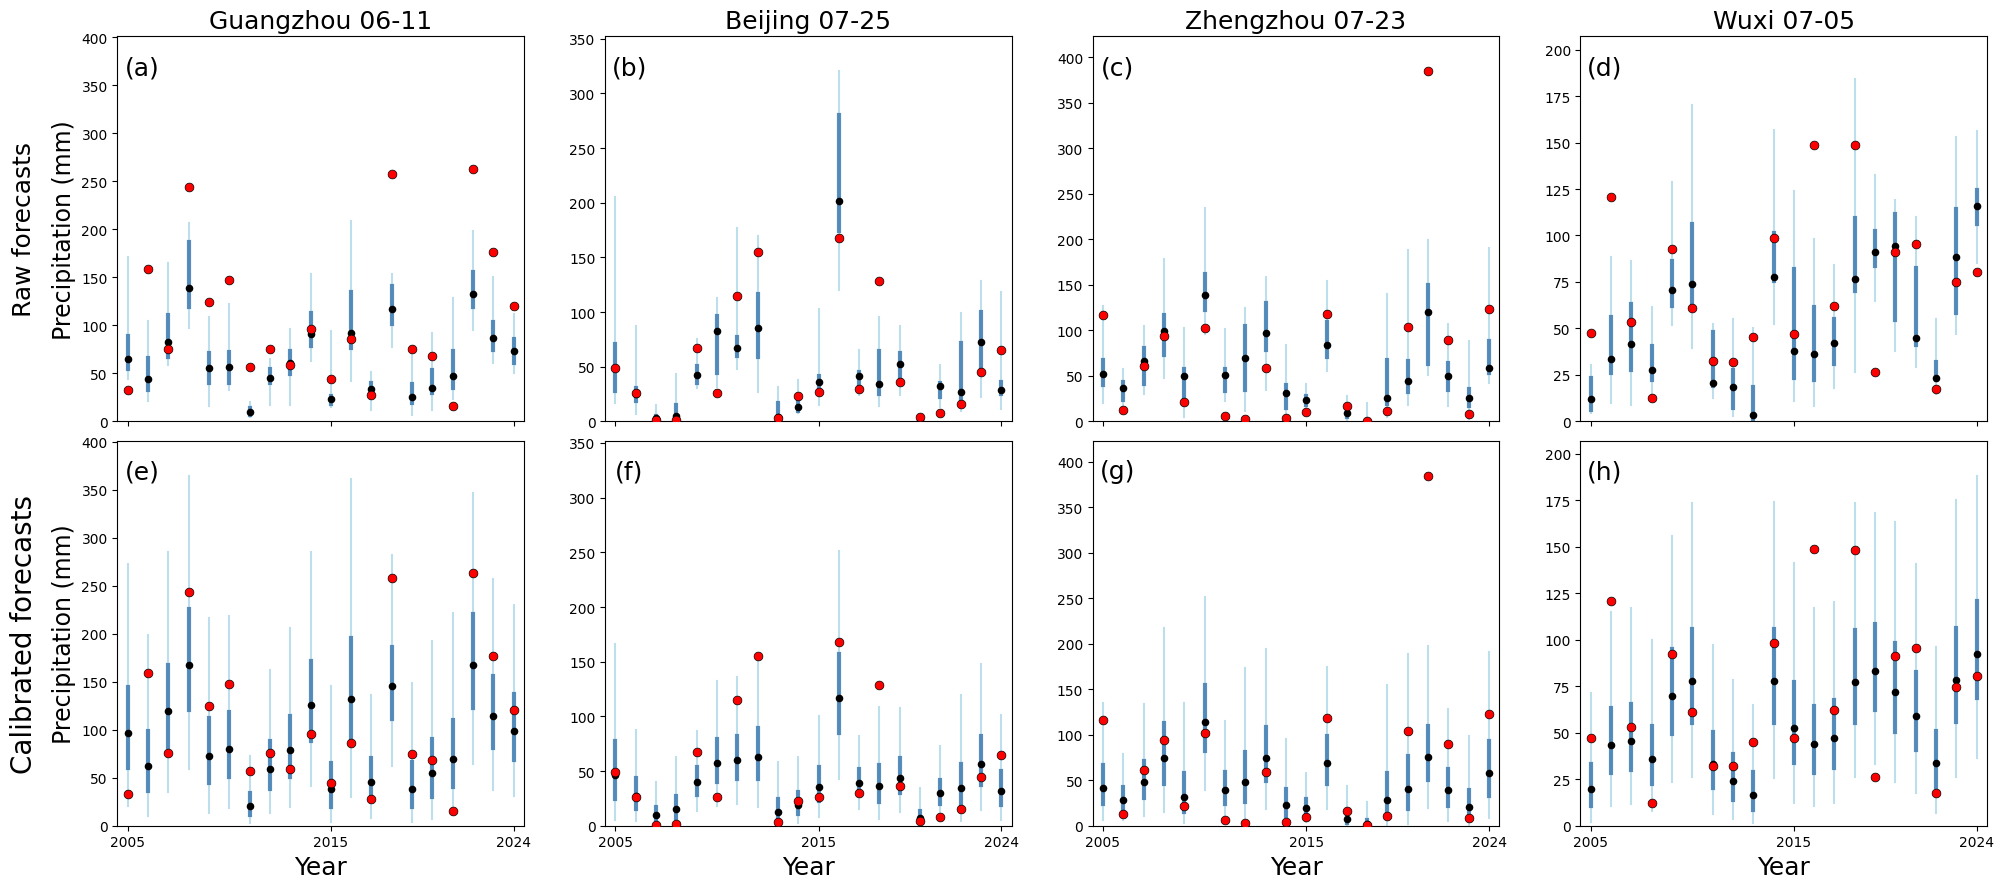

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fig, axes = plt.subplots(2, 4, figsize=(20, 9))

# 定义颜色
obs_color = 'red'
ens_10_90_color = 'lightblue'
ens_25_75_color = 'steelblue'
median_color = 'black'

# 定义年份刻度
years = [2005, 2015, 2024]

# 添加编号
def add_id(ax, id, loc=[0, 1.05], weight='normal', fontsize=12, ha='center', va='center'):
    # 将数字id转换为对应的字母 (0->a, 1->b, 2->c...)
    letter = chr(97 + id)  # 97是'a'的ASCII码
    
    # 创建带括号的编号
    id_text = f"({letter})"
    
    # 添加文本
    ax.text(loc[0], loc[1], id_text, fontsize=fontsize, weight=weight, 
            ha=ha, va=va, transform=ax.transAxes, zorder=10)

for idx, (city, data) in enumerate(results.items()):
    # 提取数据
    obs = data['obs'].values
    raw_ens = data['raw'].values
    emos_ens = data['emos'].values
    max_date = data['max_date']
    
    # 时间索引（年份）
    time_idx = pd.to_datetime(data['obs'].time.values).year
    
    # 计算百分位数
    raw_q10 = np.percentile(raw_ens, 2, axis=0)
    raw_q25 = np.percentile(raw_ens, 25, axis=0)
    raw_q75 = np.percentile(raw_ens, 75, axis=0)
    raw_q90 = np.percentile(raw_ens, 98, axis=0)
    raw_median = np.percentile(raw_ens, 50, axis=0)
    
    emos_q10 = np.percentile(emos_ens, 2, axis=0)
    emos_q25 = np.percentile(emos_ens, 25, axis=0)
    emos_q75 = np.percentile(emos_ens, 75, axis=0)
    emos_q90 = np.percentile(emos_ens, 98, axis=0)
    emos_median = np.percentile(emos_ens, 50, axis=0)
    
    x = np.arange(len(time_idx))
    
    # 计算y轴上限
    y_max = max(raw_q90.max(), emos_q90.max(), obs.max()) * 1.1
    
    # 绘制第一行（Raw）
    ax_raw = axes[0, idx]
    add_id(ax_raw, int(idx), loc=[0.06,0.92], fontsize=18)
    
    # 绘制10-90%区间（竖向线条）
    for i in range(len(x)):
        ax_raw.plot([i, i], [raw_q10[i], raw_q90[i]], color=ens_10_90_color, linewidth=1.5, alpha=0.8)
    
    # 绘制25-75%区间（竖向线条，更粗）
    for i in range(len(x)):
        ax_raw.plot([i, i], [raw_q25[i], raw_q75[i]], color=ens_25_75_color, linewidth=3, alpha=0.9)

    # 绘制集合中值（圆点）
    ax_raw.scatter(x, raw_median, color=median_color, s=20, zorder=3, label='Median')
    
    # 绘制观测值
    ax_raw.scatter(x, obs, color=obs_color, s=40, zorder=5, marker='o', edgecolors='black', linewidth=0.5, label='Observation')
    
    # 设置y轴标签
    if idx == 0:
        ax_raw.set_ylabel('Precipitation (mm)', fontsize=17)
    ax_raw.set_title(f'{city} {max_date}', fontsize=18)
    ax_raw.set_xlim(-0.5, len(x)-0.5)
    ax_raw.set_ylim(0, y_max)
    
    # 添加Raw forecasts文字（左侧）
    if idx == 0:
        ax_raw.text(-0.23, 0.5, 'Raw forecasts', transform=ax_raw.transAxes, 
                rotation=90, va='center', ha='center', fontsize=18)
    
    # 设置x轴刻度（每个子图都显示）
    year_positions = []
    year_labels = []
    for year in years:
        if year in time_idx.values:
            year_pos = np.where(time_idx.values == year)[0][0]
            year_positions.append(year_pos)
            year_labels.append(str(year))
    
    ax_raw.set_xticks(year_positions)
    ax_raw.set_xticklabels([])
    
    # 绘制第二行（Calibrated）
    ax_cal = axes[1, idx]
    add_id(ax_cal, int(idx+4), loc=[0.06,0.92], fontsize=18)

    # 绘制10-90%区间（竖向线条）
    for i in range(len(x)):
        ax_cal.plot([i, i], [emos_q10[i], emos_q90[i]], color=ens_10_90_color, linewidth=1.5, alpha=0.8)
    
    # 绘制25-75%区间（竖向线条，更粗）
    for i in range(len(x)):
        ax_cal.plot([i, i], [emos_q25[i], emos_q75[i]], color=ens_25_75_color, linewidth=3, alpha=0.9)
    
    # 绘制集合中值（圆点）
    ax_cal.scatter(x, emos_median, color=median_color, s=20, zorder=3)
    
    # 绘制观测值
    ax_cal.scatter(x, obs, color=obs_color, s=40, zorder=5, marker='o', edgecolors='black', linewidth=0.5)
    
    # 设置y轴标签
    if idx == 0:
        ax_cal.set_ylabel('Precipitation (mm)', fontsize=17)
    ax_cal.set_xlim(-0.5, len(x)-0.5)
    ax_cal.set_ylim(0, y_max)
    
    # 添加Calibrated forecasts文字（左侧）
    if idx == 0:
        ax_cal.text(-0.23, 0.5, 'Calibrated forecasts', transform=ax_cal.transAxes, 
        rotation=90, va='center', ha='center',  fontsize=20)
    
    # 设置x轴刻度（每个子图都显示）
    ax_cal.set_xticks(year_positions)
    ax_cal.set_xticklabels(year_labels)
    ax_cal.set_xlabel('Year', fontsize=18)

plt.tight_layout()
plt.subplots_adjust(hspace=0.05, wspace=0.2)
plt.show()